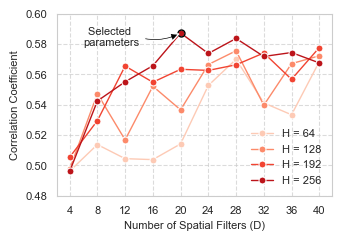

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = ['BCIIV', 'Stanford']
decoder = 'HiLoFuseNet'
CNN_Ds = [4,8,12,16,20,24,28,32,36,40]
LSTM_hiddensizes = [64,128,192,256]
selected_D = 20

cc_varingHid = []
for hid in LSTM_hiddensizes:
    cc_varingD = []
    for d in CNN_Ds:
        cc = []
        for dataset in datasets:
            # 5 * N matrix
            cc_temp = np.load(f'results/o5/hyperparameter/{dataset}_{decoder}_mse_seed42_win2.8_d{d}_hid{hid}_o5_cc.npy')
            cc.extend(np.mean(cc_temp, axis=0))

        cc_varingD.append(np.mean(cc))

    cc_varingHid.append(cc_varingD)

cc_varingHid = np.array(cc_varingHid).T
df = pd.DataFrame(cc_varingHid, columns=[f'H = {h}' for h in LSTM_hiddensizes])
df['CNN_D'] = CNN_Ds

df_long = pd.melt(
    df,
    id_vars=['CNN_D'],
    value_vars=[col for col in df.columns if col.startswith('H = ')],
    var_name='LSTM Hidden Size',
    value_name='Mean Correlation'
)

cm = 1 / 2.54
plt.figure(figsize=(9*cm, 6*cm))

sns.lineplot(
    data=df_long,
    x='CNN_D',
    y='Mean Correlation',
    hue='LSTM Hidden Size',
    palette='Reds',
    linewidth=1,
    marker='o',
    markersize=5
)

plt.xticks(CNN_Ds, labels=CNN_Ds, rotation=0)
plt.xlabel('Number of Spatial Filters (D)', fontsize=8)
plt.ylabel('Correlation Coefficient', fontsize=8)
plt.ylim(0.48, 0.6)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tick_params(labelsize=8)
plt.legend(
    frameon=False,
    prop={'size': 8},
    loc='lower right',
)

# mark the selected hyperparameter
target_cc = df_long[
    (df_long['CNN_D'] == selected_D) &
    (df_long['LSTM Hidden Size'] == 'H = 256')
]['Mean Correlation'].iloc[0]

plt.plot(selected_D, target_cc, 'o', color='black', markersize=5, markeredgecolor='black', markerfacecolor='none', linestyle='None')

plt.annotate(
    'Selected \nparameters',
    xy=(selected_D, target_cc),
    xytext=(selected_D -10, target_cc - 0.01),
    arrowprops=dict(
        facecolor='black',
        shrink=0.05,
        width=1.5,
        headwidth=6,
        headlength=6,
        connectionstyle="arc3,rad=.2"
    ),
    horizontalalignment='center',
    verticalalignment='bottom',
    fontsize=8
)

figPath = 'E:/my papers/finger decoding/HiLoFuseNet/Manuscript/figures/'
plt.savefig(figPath + 'hyperparameter.png', dpi=300, bbox_inches='tight')
plt.show()
